# [일반 CNN모델]

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [ ]:
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =============================================================================
# 1. 설정 (Configuration) & 데이터 다운로드
# =============================================================================
# 시드 고정 (재현성 확보)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" 현재 사용 장치: {device}")

# 데이터 경로 설정 (Kaggle 환경 기준)
# 만약 코랩이고 데이터가 없다면 아래 주석을 풀어 다운로드 명령을 실행해야 합니다.
# !pip install -q kaggle
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/  # kaggle.json 파일을 업로드했다고 가정
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
# !unzip -q chest-xray-pneumonia.zip

base_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray'
# 경로가 없으면(로컬/코랩 등) 경로를 수정하세요. 예: base_dir = './chest_xray'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

 현재 사용 장치: cuda


In [ ]:


# 하이퍼파라미터
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

print(f" 데이터 경로 확인:\n - Train: {train_dir}\n - Val: {val_dir}\n - Test: {test_dir}")

# =============================================================================
# 2. 데이터 전처리 및 증강 (Transforms)
# =============================================================================
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

# [Train]: 안전한 증강 (회전 X, 이동 O, 밝기 O)
train_transform = v2.Compose([
    v2.Resize(IMAGE_SIZE),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)), # 상하좌우 10% 이동
    v2.ColorJitter(brightness=0.1, contrast=0.1),     # 밝기/대비 변화
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
])

# [Val / Test]: 원본 유지 (정규화만 적용)
val_test_transform = v2.Compose([
    v2.Resize(IMAGE_SIZE),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=mean, std=std)
])

# =============================================================================
# 3. 데이터 로더 (Data Loaders) - 규칙 준수!
# =============================================================================
# 폴더 구조를 그대로 사용하여 데이터셋 생성
try:
    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
    test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)
except FileNotFoundError:
    print(" 에러: 데이터 경로를 찾을 수 없습니다. 경로를 확인해주세요.")
    raise

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"데이터 로드 완료")
print(f"   - 학습(Train): {len(train_dataset)}장")
print(f"   - 검증(Val): {len(val_dataset)}장 ( 데이터가 적으므로 검증 점수 변동이 클 수 있음)")
print(f"   - 평가(Test): {len(test_dataset)}장")
print(f"   - 클래스: {train_dataset.classes}")

 데이터 경로 확인:
 - Train: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
 - Val: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
 - Test: /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
데이터 로드 완료
   - 학습(Train): 5216장
   - 검증(Val): 16장 ( 데이터가 적으므로 검증 점수 변동이 클 수 있음)
   - 평가(Test): 624장
   - 클래스: ['NORMAL', 'PNEUMONIA']


In [ ]:


# =============================================================================
# 4. 불균형 해결 (Class Weights Calculation)
# =============================================================================
# Train 데이터의 클래스 개수 확인
targets = train_dataset.targets
count_normal = targets.count(0)
count_pneumonia = targets.count(1)

print(f" 클래스 비율 - Normal: {count_normal}, Pneumonia: {count_pneumonia}")

# 가중치 계산: (많은 쪽 개수 / 적은 쪽 개수)
weight_normal = count_pneumonia / count_normal
weight_pneumonia = 1.0

class_weights = torch.tensor([weight_normal, weight_pneumonia]).to(device)
print(f" 적용될 Loss 가중치: {class_weights}")

# =============================================================================
# 5. 모델 정의 (CustomCNN)
# =============================================================================
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CustomCNN(num_classes=2).to(device)

# 손실함수(가중치 적용) 및 옵티마이저
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)




 클래스 비율 - Normal: 1341, Pneumonia: 3875
 적용될 Loss 가중치: tensor([2.8896, 1.0000], device='cuda:0')


In [ ]:
# =============================================================================
# 6. 학습 루프 (Training Loop)
# =============================================================================
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
history = {'train_loss': [], 'train_acc': [], 'val_acc': []}

print("\n 학습 시작...")

for epoch in range(NUM_EPOCHS):
    # [훈련 단계]
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    # [검증 단계] - 16장 데이터로 수행
    model.eval()
    val_corrects = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    val_acc = val_corrects.double() / len(val_dataset)

    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc.item())
    history['val_acc'].append(val_acc.item())

    print(f"Ep {epoch+1}/{NUM_EPOCHS} | Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | Val Acc: {val_acc:.4f}")

    # 모델 저장 (Val 점수가 같거나 높으면 갱신)
    if val_acc >= best_acc:
        best_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

print(f"\n 학습 완료! Best Val Acc: {best_acc:.4f}")
model.load_state_dict(best_model_wts) # 최고 모델로 복원



 학습 시작...
Ep 1/10 | Loss: 0.4012 | Train Acc: 0.8089 | Val Acc: 0.8750
Ep 2/10 | Loss: 0.2254 | Train Acc: 0.9086 | Val Acc: 0.9375
Ep 3/10 | Loss: 0.1745 | Train Acc: 0.9289 | Val Acc: 0.8125
Ep 4/10 | Loss: 0.1827 | Train Acc: 0.9277 | Val Acc: 1.0000
Ep 5/10 | Loss: 0.1706 | Train Acc: 0.9358 | Val Acc: 1.0000
Ep 6/10 | Loss: 0.1573 | Train Acc: 0.9396 | Val Acc: 0.8125
Ep 7/10 | Loss: 0.1335 | Train Acc: 0.9454 | Val Acc: 0.9375
Ep 8/10 | Loss: 0.1331 | Train Acc: 0.9500 | Val Acc: 0.8125
Ep 9/10 | Loss: 0.1411 | Train Acc: 0.9463 | Val Acc: 0.7500
Ep 10/10 | Loss: 0.1199 | Train Acc: 0.9534 | Val Acc: 0.9375

 학습 완료! Best Val Acc: 1.0000


<All keys matched successfully>

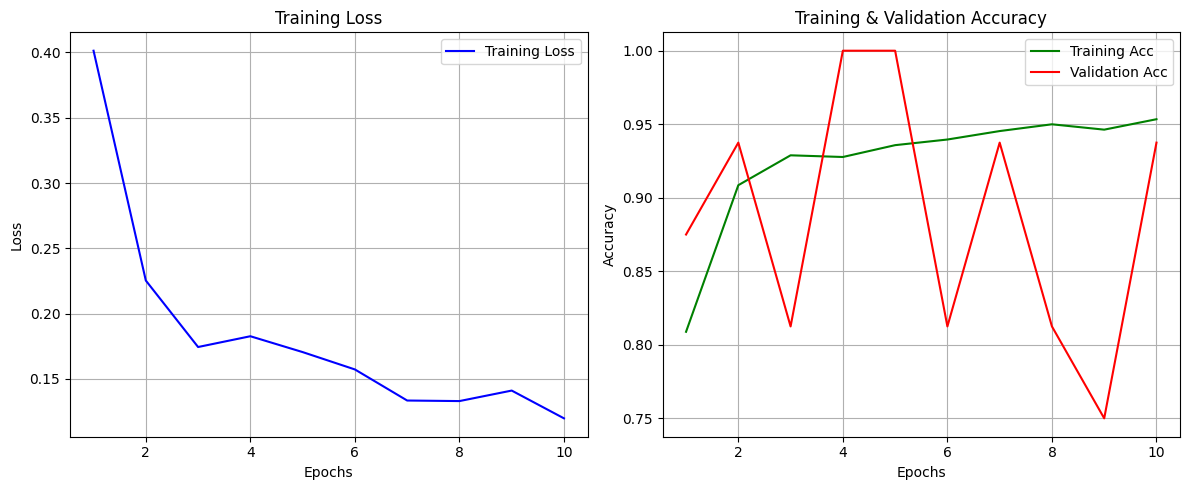

In [ ]:
import matplotlib.pyplot as plt

# 시각화 함수 정의
def plot_training_history(history):
    # 에폭 수 계산 (history 리스트의 길이로 파악)
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # 1. 학습 손실 (Train Loss) 그래프
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # 2. 학습 및 검증 정확도 (Train & Val Accuracy) 그래프
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'g-', label='Training Acc')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# 그래프 그리기 실행
plot_training_history(history)

## [모델시각화- 위의 결과 해석]
- 그래프에서는 검증(Validation) 데이터의 개수가 너무 적어서 그래프가 '튀는' 것이며,
- 실제 학습은 정상적으로 잘 되었습니다.

1. 그래프가 요동치는 이유: "표본의 부족"
  - 코드 주석에  [검증 단계] - 16장 데이터가 핵심 원인입니다.
  - Val Acc (빨간선)의 들쭉날쭉함:
  - 검증 데이터가 16장밖에 없기 때문에, 모델이 단 1장만 더 맞거나 틀려도 정확도가 약 6.25% (1/16)씩 확확 바뀝니다.
      ◦ 그래프에서 정확도가 1.0(100%)을 찍었다가 0.81(81%) 등으로 급락하는 패턴은, 16장 중 1~2장을 틀렸냐 맞았냐에 따라 점수가 널뛰기 때문입니다.
2. Train Loss (파란선)의 안정성:
  - 반면 학습 데이터는 양이 충분하므로 Loss가 아주 부드럽고 예쁘게 우하향하고 있습니다. 이는 모델이 패턴을 아주 잘 학습하고 있다는 증거입니다.# 새 섹션


 최종 테스트 데이터 평가 중...

 최종 테스트 정확도 (Accuracy): 87.66%

 상세 분류 리포트:
              precision    recall  f1-score   support

      Normal       0.92      0.74      0.82       234
   Pneumonia       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.86       624
weighted avg       0.88      0.88      0.87       624



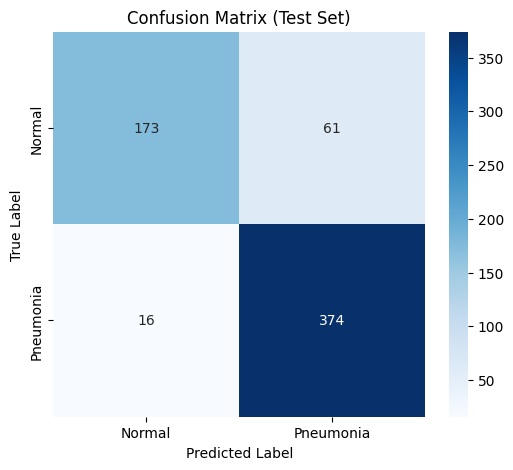

In [ ]:
# =============================================================================
# 7. 최종 평가 (Evaluation on Test Set)
# =============================================================================
print("\n 최종 테스트 데이터 평가 중...")

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 결과 출력
print("\n" + "="*50)
print(f" 최종 테스트 정확도 (Accuracy): {accuracy_score(all_labels, all_preds)*100:.2f}%")
print("="*50)

# 분류 리포트
print("\n 상세 분류 리포트:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

# 혼동 행렬 시각화
plt.figure(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

# [테스트데이터검증- 위의결과해석]
### 1. 테스트 결과가 잘 나온 이유: "통계적 안정성"

최종 테스트 결과는 **624장(Support 합계)**의 데이터를 사용했습니다.

  - **충분한 모집단:** 16장이 아닌 624장으로 평가했기 때문에, 운에 의한 변동이 사라졌습니다.
  - **학습의 성과:** `Train Loss`가 0.12 수준까지 떨어진 것을 보면, 모델은 폐렴의 특징(Feature)을 이미 충분히 잘 파악했습니다. 검증 그래프만 불안해 보였을 뿐, 내부 가중치(Weight)는 잘 훈련되었습니다.

### 2. 상세 리포트 해석 (의료적 관점)
결과가 단순히 "잘 나왔다"를 넘어, 의료 AI 관점에서 꽤 **의미 있는 결과**입니다.

- **Pneumonia (폐렴) Recall: 0.96 (매우 중요)**
    - **의미:** 실제 폐렴 환자 100명 중 **96명을 찾아냈다는 뜻**입니다.
    - 의료 진단 모델에서는 '병이 있는데 없다고 하는 것(False Negative)'이 가장 위험합니다. 96%의 재현율(Recall)은 놓친 환자가 거의 없다는 뜻으로, **스크리닝 도구로서 가치가 높습니다.**
- **Normal (정상) Recall: 0.74**
    - **의미:** 정상인 중 일부를 폐렴으로 의심했다는 뜻입니다(과잉 진단 경향).
    - 하지만 실제 병원에서 의사에게 "의심되니 확인해 보세요"라고 알려주는 보조 도구(CDSS)로서는, 환자를 놓치는 것보다 약간 예민하게 반응하는 것이 낫습니다.

### 3. 혼돈행렬분석
- 가장 훌륭한 점 (Recall):
  - 실제 폐렴 환자(390명) 중 374명을 찾아냈습니다.
  - 놓친 환자(False Negative)는 16명뿐입니다.
  - 의료 현장에서는 환자를 돌려보내는 것(놓치는 것)이 가장 치명적인데, 이 비율을 4% 수준으로 잘 막았습니다.

- 개선할 점 (Precision):
  - 정상인(234명) 중 61명을 폐렴으로 의심했습니다.
  - 이것은 "정상 폐 사진에서도 뭔가 폐렴스러운 특징(흐릿함 등)을 예민하게 잡아냈다"는 뜻입니다. 의사가 다시 확인하면 되는 문제이므로, 놓치는 것보다는 훨씬 낫습니다.

# [설명가능한 XAI]

이 시각화 자료를 캡처해서 보고서나 발표 자료에 넣으면 "AI가 단순히 맞춘 게 아니라, 의학적 근거(폐의 음영)를 보고 판단했다"는 것을 증명할 수 있습니다.

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 72.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=d075cfb47fcad2d59b12a2a6817934e9d3ab0a9184e864211c41e6a52f9d9dbc
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


### [결과 해석 방법]
- 코드를 실행하면 이미지가 두 장씩 짝지어 나올 겁니다.
- 왼쪽 (Original): 원본 엑스레이 사진입니다.
- 오른쪽 (Grad-CAM): 원본 위에 붉은색/노란색 히트맵이 덮여 있습니다.
- 붉은색 영역: 모델이 "여기가 폐렴의 증거야!"라고 강력하게 판단한 부위입니다.
- 파란색 영역: 판단에 별 영향을 주지 않은 부위입니다.

- 성공적인 결과란?
  - 폐렴(Pneumonia) 사진일 때: 붉은 영역이 폐 안쪽의 뿌연 부분(음영)에 집중되어 있다면 모델이 정확히 병변을 보고 있는 것입니다. (만약 폐가 아니라 쇄골 뼈나 배경을 보고 있다면 모델이 꼼수를 부린 것입니다.)

  - 정상(Normal) 사진일 때: 특정 부위보다는 전체적으로 파랗거나, 폐 전체를 넓게 훑어보는 경향이 있을 수 있습니다.

In [ ]:
# Conv2모델 마지막 이름확인 여기서는 Conv2임
print(model)

CustomCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (avgpool): AdaptiveAvgPool2d(output_size=(7, 7))
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


### [코드-정상사진 XAI]

Grad-CAM 분석 중...


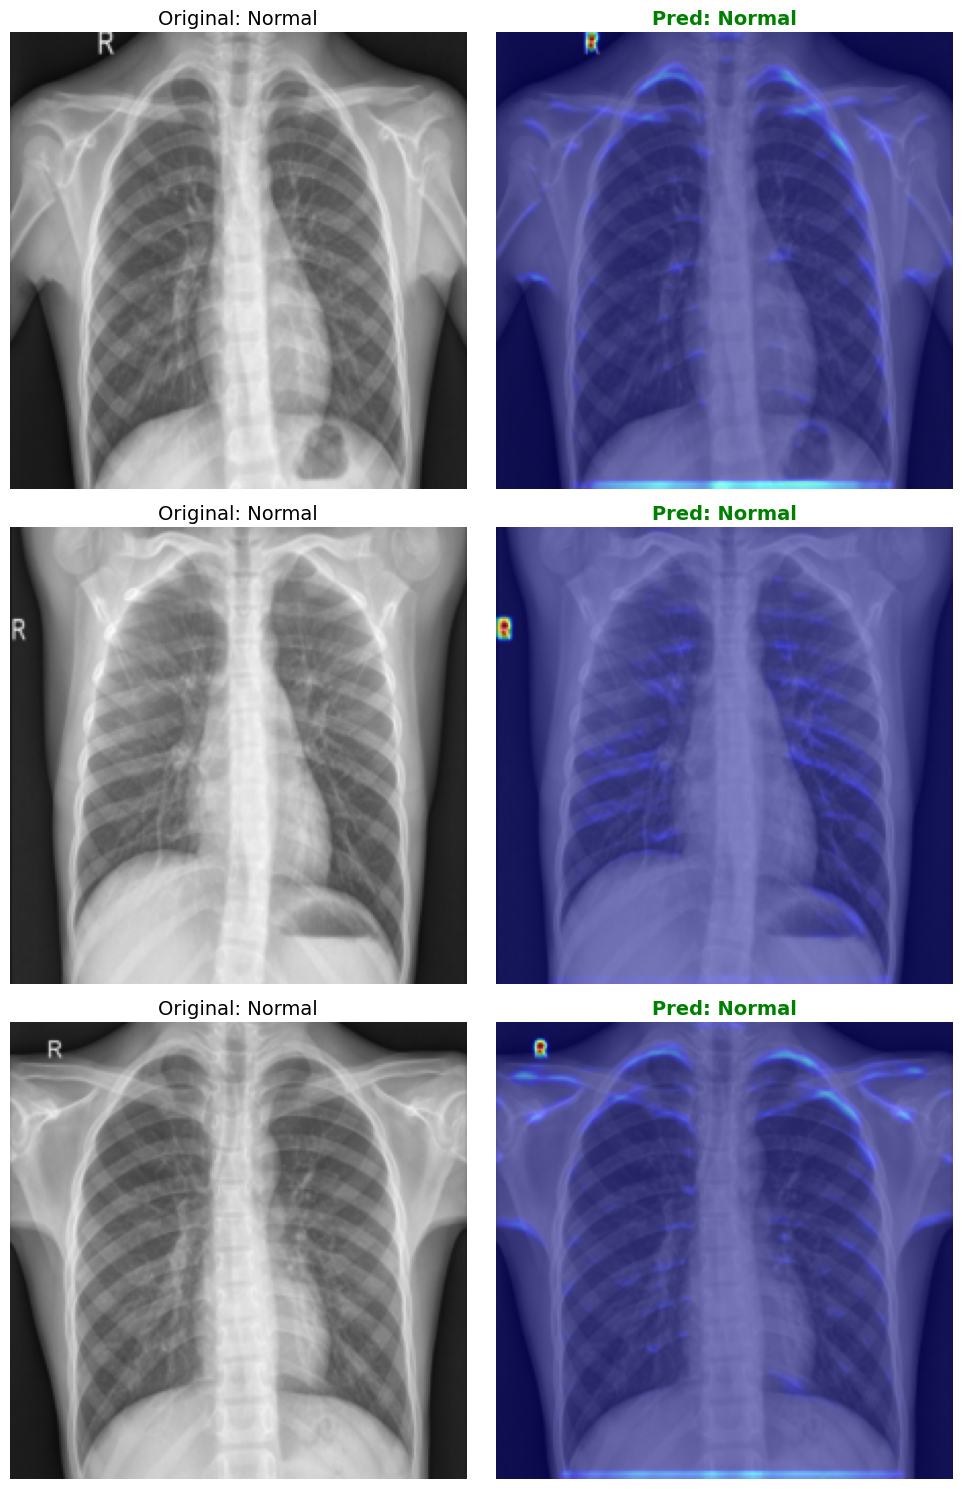

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# ==========================================
# [수정된 부분] 마지막 컨볼루션 층 지정
# 님 모델의 마지막 conv 층 이름인 'conv2'를 넣습니다.
# ==========================================
target_layers = [model.conv2]

# Grad-CAM 객체 생성
cam = GradCAM(model=model, target_layers=target_layers)

def visualize_gradcam(model, data_loader, device, count=3):
    model.eval()

    # 데이터 로더에서 배치 하나 가져오기
    images, labels = next(iter(data_loader))
    images = images.to(device)

    # 이미지 정규화 해제 (시각화를 위해 원본 밝기로 복구)
    # 학습 때 사용한 mean, std 값과 동일해야 합니다.
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # 시각화할 이미지 개수만큼 행 생성
    fig, axes = plt.subplots(count, 2, figsize=(10, 5 * count))

    for i in range(count):
        input_tensor = images[i].unsqueeze(0) # 배치 차원 추가
        label_idx = labels[i].item()

        # 모델 예측
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        pred_idx = pred.item()

        # Grad-CAM 생성
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)
        grayscale_cam = grayscale_cam[0, :]

        # 원본 이미지 시각화 준비
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = std * img + mean # 정규화 복원
        img = np.clip(img, 0, 1) # 0~1 사이로 클리핑

        # 히트맵을 원본 이미지에 덮어씌우기
        visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

        # 클래스 이름 (0: Normal, 1: Pneumonia)
        class_names = ['Normal', 'Pneumonia']
        title_color = 'green' if label_idx == pred_idx else 'red'

        # 왼쪽: 원본
        ax_orig = axes[i, 0] if count > 1 else axes[0]
        ax_orig.imshow(img)
        ax_orig.set_title(f"Original: {class_names[label_idx]}", fontsize=14)
        ax_orig.axis('off')

        # 오른쪽: Grad-CAM
        ax_cam = axes[i, 1] if count > 1 else axes[1]
        ax_cam.imshow(visualization)
        ax_cam.set_title(f"Pred: {class_names[pred_idx]}", color=title_color, fontsize=14, fontweight='bold')
        ax_cam.axis('off')

    plt.tight_layout()
    plt.show()

# 실행
print("Grad-CAM 분석 중...")
visualize_gradcam(model, test_loader, device, count=3)

### [정상사진_XAI시각화 해석]

세 장의 사진 모두 Original: Normal (실제 정상)이며, 모델도Pred: Normal (정상 예측)로 완벽하게 맞췄습니다.

1. "파란색"이 많은 이유 (매우 긍정적)
- 히트맵의 색상: Grad-CAM에서 붉은색은 "이 부분을 보고 판단했다"는 뜻이고, 파란색은 "별 특징이 없다"는 뜻입니다.
- 정상의 특징: 폐렴 환자는 폐에 '하얀 음영(Infiltrates)'이라는 뚜렷한 특징이 있지만, 정상인의 폐는 '깨끗함' 그 자체가 특징입니다. 즉, 모델이 보기에 "어? 여기도 깨끗하고, 저기도 깨끗하네? 특이한 게 없으니 정상이군."이라고 판단한 것입니다.
- 결론: 폐 부위에 강렬한 붉은색 영역이 없이 전체적으로 푸르스름한 것은, 모델이 억지로 특징을 찾아내려 하지 않고 폐가 깨끗하다는 것을 올바르게 인지했다는 신호입니다.

2. 소소한 발견 (AI의 시선)
- 사진의 구석이나 어깨 쪽을 자세히 보면 약간의 노란색/붉은색 점들이 보입니다 (특히 두 번째, 세 번째 사진의 왼쪽 상단 'R' 마커 근처).
-이것은 모델이 "폐 안쪽이 깨끗한 것"을 확인한 뒤, 보조적으로 뼈(쇄골)나 사진의 마커('R') 같은 배경 정보를 힌트로 사용했을 가능성이 있습니다.

하지만 가장 중요한 폐 내부(Lung Field)에는 붉은 점을 찍지 않았으므로, "오진(False Positive)"을 하지 않고 잘 넘어가고 있습니다.

### [코드-폐렴사진 XAI]

폐렴 케이스만 찾아서 분석 중...


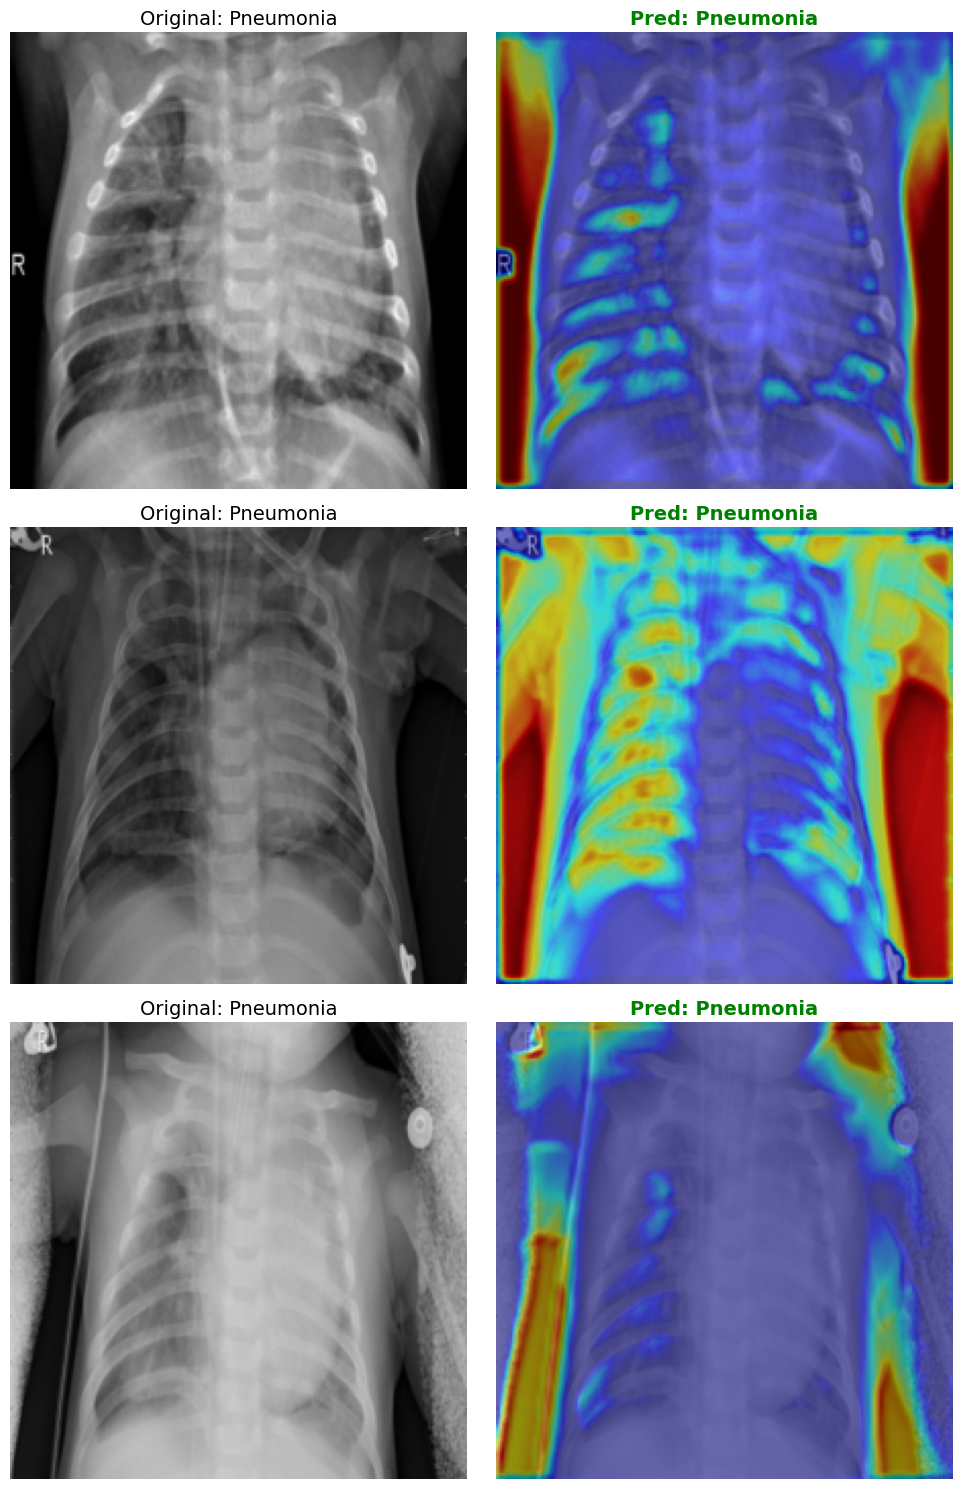

In [ ]:
# 폐렴(Pneumonia, 라벨 1)인 케이스만 골라서 시각화하기
def visualize_pneumonia_only(model, data_loader, device, count=3):
    model.eval()
    found_count = 0

    # 시각화 설정
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # 그릴 공간 준비
    fig, axes = plt.subplots(count, 2, figsize=(10, 5 * count))

    # 배치 단위로 데이터를 가져오며 폐렴 찾기
    for images, labels in data_loader:
        images = images.to(device)

        for i in range(len(labels)):
            if found_count >= count:
                plt.tight_layout()
                plt.show()
                return

            # 라벨이 1(Pneumonia)인 경우만 처리
            if labels[i].item() == 1:
                input_tensor = images[i].unsqueeze(0)

                # 모델 예측
                output = model(input_tensor)
                _, pred = torch.max(output, 1)
                pred_idx = pred.item()

                # Grad-CAM 생성
                grayscale_cam = cam(input_tensor=input_tensor, targets=None)
                grayscale_cam = grayscale_cam[0, :]

                # 이미지 복원
                img = images[i].cpu().permute(1, 2, 0).numpy()
                img = std * img + mean
                img = np.clip(img, 0, 1)

                visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

                class_names = ['Normal', 'Pneumonia']
                title_color = 'green' if 1 == pred_idx else 'red' # 1은 실제 Pneumonia

                # 그리기
                ax_orig = axes[found_count, 0]
                ax_orig.imshow(img)
                ax_orig.set_title(f"Original: Pneumonia", fontsize=14)
                ax_orig.axis('off')

                ax_cam = axes[found_count, 1]
                ax_cam.imshow(visualization)
                ax_cam.set_title(f"Pred: {class_names[pred_idx]}", color=title_color, fontsize=14, fontweight='bold')
                ax_cam.axis('off')

                found_count += 1

print("폐렴 케이스만 찾아서 분석 중...")
visualize_pneumonia_only(model, test_loader, device, count=3)

## [폐렴사진-XAI 시각화 해석]

        - 폐렴의 특징(곰팡이): 폐렴에 걸리면 폐 속에 염증이 차면서
          X-ray 상에서 '뿌옇고 흐릿한 구름 같은 무늬(침윤)'가 나타납니다.
        - 배경의 특징: 뼈는 하얗고 딱딱한 선이고, 배경은 새카만 색입니다.
            여기에는 '뿌연 구름' 무늬가 절대 생기지 않습니다.
        - AI의 학습: 모델은 "뿌연 구름 무늬가 있으면 폐렴이다!"라는 규칙을 찾아냈습니다.
        - 결과: 그 '뿌연 구름 무늬'는 해부학적으로 오직 폐 안쪽에만 존재합니다.
          그래서 모델이 그 무늬를 따라 색칠을 했더니, 폐 모양(폐 실질)을 따라가게 된 것입니다.


모델이 단순히 운으로 맞춘 게 아니라, "폐렴의 특징적 징후"를 정확하게 포착하고 있다는 것을 증명하는 결과임

1. "붉은색"의 위치: 정확히 폐를 겨냥함
- 히트맵 분석: 3장의 사진 모두 붉은색(Red)과 노란색(Yellow)의 강한 활성화 영역이 흉곽(갈비뼈) 안쪽의 폐 영역에 집중되어 있습니다.
- 의미: 모델이 배경(검은색)이나 다른 신체 부위(배, 머리 등)가 아니라, 병변이 존재하는 폐 실질(Lung Parenchyma)을 보고 판단했다는 뜻입니다.

2. 폐렴의 특징인 "혼탁함(Opacity)"을 감지
- 의학적 관점: X-ray에서 폐렴은 폐포에 염증 물질이 차면서 하얗게 보이는 폐 침윤(Infiltrates)이나 음영 증가(Opacity)로 나타납니다.

- AI의 시선:
  - 첫 번째 사진: 양쪽 폐, 특히 오른쪽(사진상 왼쪽) 폐의 뿌연 부분에 붉은색이 넓게 퍼져 있습니다.
  - 두 번째 사진: 폐 전체에 걸쳐 있는 불규칙한 패턴을 강하게 감지하고 있습니다.
  - 세 번째 사진: 폐의 가장자리와 내부의 텍스처가 복잡한 부분을 붉게 표시하고 있습니다.

이는 모델이 "폐 안쪽이 깨끗하지 않고(Normal과 다름), 뭔가 복잡하고 하얀 것이 껴있다"는 특징을 '폐렴'의 근거로 삼았음을 보여줍니다.

## [코드없음-오류데이터만 분석하는 XAI필요함]